## Notebook to test .py implementation workflow

In [1]:
import numpy as np

from src.utils.seed import set_seed
from src.utils.plotting import plot_learning_curve
from src.utils.env import make_env
from src.utils.stats import compute_stats
from experiments.pendulum import run_experiments
from src.algorithms.td3 import TD3Agent

In [2]:
# -----------------------
# Random baseline agent
# (placeholder for DQN/PPO/etc.)
# -----------------------
class RandomAgent:
    """
    A simple agent that takes random actions in the environment.
    This is a baseline for testing our environment and code setup.
    """
    def __init__(self, action_space):
        self.action_space = action_space

    def act(self, state):
        return self.action_space.sample()
    def set_eval_mode(self, mode: bool):
        pass

In [3]:
print("Running experiments with RandomAgent")
rnd_logs = run_experiments(
    agent_fn=lambda action_space, state_dim: RandomAgent(action_space),
    seeds=[0, 1, 2],
    n_episodes=20,
    eval_interval=5
)

print("Running experiments with TD3Agent")

td3_logs = run_experiments(
    agent_fn=lambda action_space, state_dim: TD3Agent(
        action_space=action_space,
        state_dim=state_dim,
        gamma=0.99,
        batch_size=64,
        lr=3e-4,
        sigma=0.1,
        sigma_tilde=0.2,
        c=0.5,
        tau=0.005,
        policy_delay=2,
        buffer_capacity=20000
),
    seeds=[0, 1, 2],
    n_episodes=300,
    eval_interval=10
)

Running experiments with RandomAgent
Running experiments with TD3Agent


Plot saved to: results/plots/2026-05-15_16-52/learning_curve.png


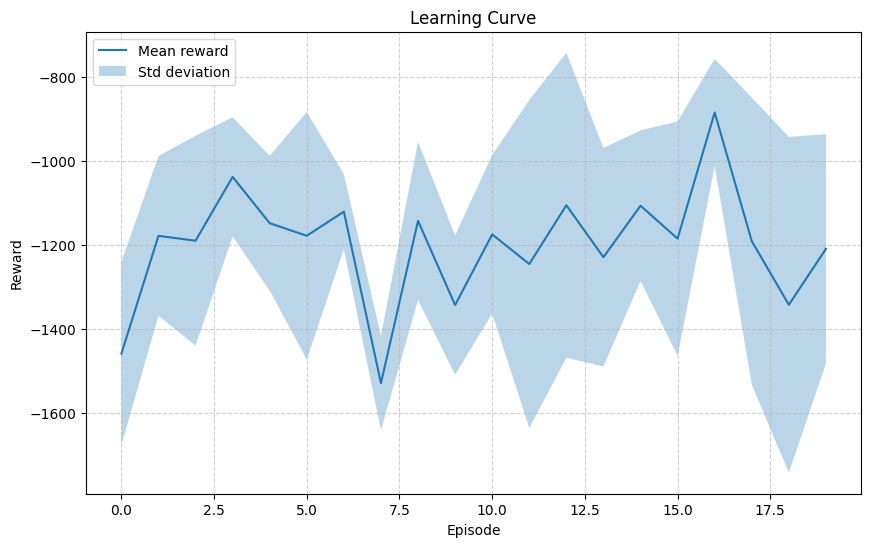

In [4]:
rewards_rnd = [logger.episode_rewards for logger in rnd_logs]
mean_rewards_rnd, std_rewards_rnd = compute_stats(rewards_rnd)
episodes = np.arange(len(mean_rewards_rnd))

plot_learning_curve(episodes, mean_rewards_rnd, std_rewards_rnd)

Plot saved to: results/plots/2026-05-15_16-52/learning_curve.png


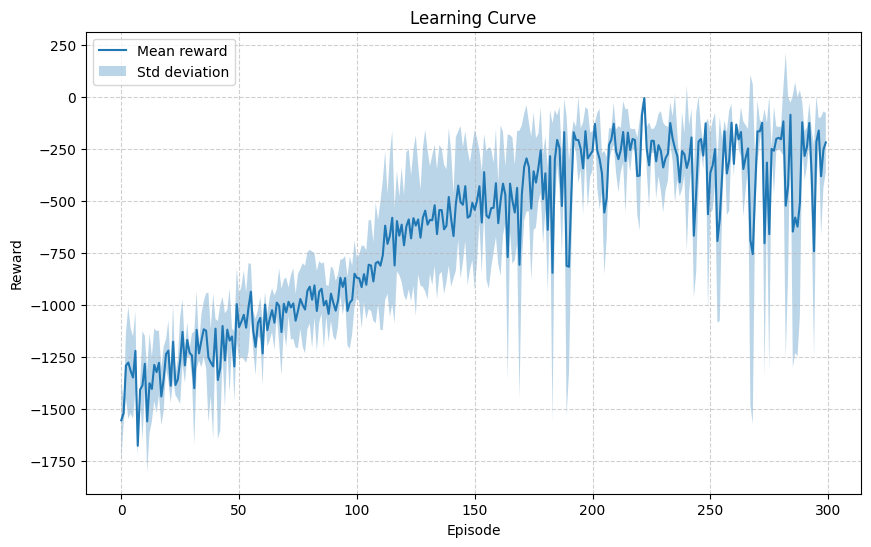

In [5]:
rewards_td3 = [logger.episode_rewards for logger in td3_logs] 
mean_rewards_td3, std_rewards_td3 = compute_stats(rewards_td3)
episodes = np.arange(len(mean_rewards_td3))

plot_learning_curve(episodes, mean_rewards_td3, std_rewards_td3)

In [6]:
# plot evaluation rewards
eval_rewards_dqn = [logger.eval_rewards for logger in dqn_logs]
mean_eval_rewards_dqn, std_eval_rewards_dqn = compute_stats(eval_rewards_dqn)
eval_episodes = np.arange(len(mean_eval_rewards_dqn)) * 10
plot_learning_curve(eval_episodes, mean_eval_rewards_dqn, std_eval_rewards_dqn)

NameError: name 'dqn_logs' is not defined

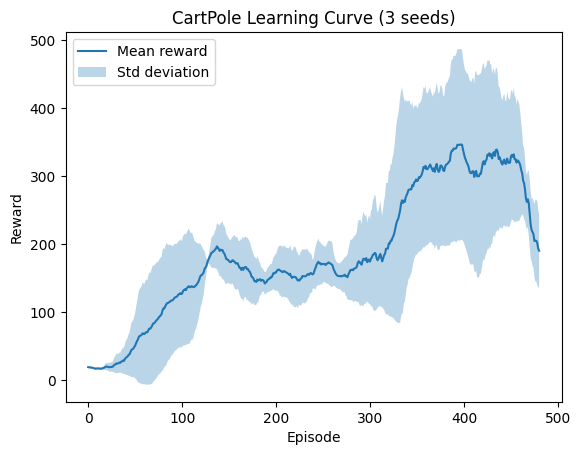

In [ ]:
# plot episode reward (for dqn) with moving average

mva_ep_rewards_dqn = [logger.moving_average(window=20) for logger in dqn_logs]
mean_ep_rewards_dqn, std_ep_rewards_dqn = compute_stats(mva_ep_rewards_dqn)
episodes = np.arange(len(mean_ep_rewards_dqn))
plot_learning_curve(episodes, mean_ep_rewards_dqn, std_ep_rewards_dqn)

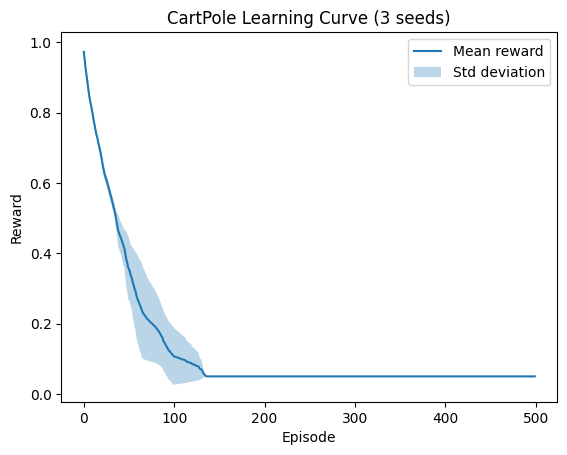

In [ ]:
# plot epsilon decay for dqn
epsilons_dqn = [logger.epsilons for logger in dqn_logs]
mean_epsilons_dqn, std_epsilons_dqn = compute_stats(epsilons_dqn)
episodes = np.arange(len(mean_epsilons_dqn))
plot_learning_curve(episodes, mean_epsilons_dqn, std_epsilons_dqn)

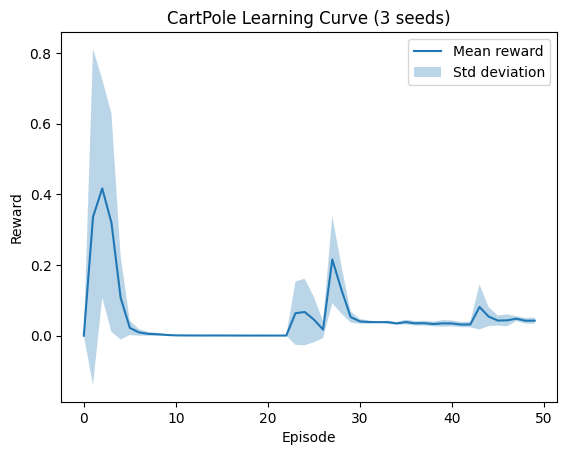

In [ ]:
losses_dqn = np.array([logger.losses for logger in dqn_logs])
min_len = min(len(l) for l in losses_dqn)
losses_dqn = np.array([l[:min_len] for l in losses_dqn])

losses_mean = losses_dqn.mean(axis=0)
losses_std = losses_dqn.std(axis=0)

episodes = np.arange(min_len)

plot_learning_curve(episodes[:50], losses_mean[:50], losses_std[:50])